In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


C:\Users\Local Admin\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
joined_lfes_fp = '../data/calculated/Joined_LFEs_w_phases.csv'

#LFE_df = pd.read_csv('../data/calculated/lfe_detections_unet.csv', parse_dates=['start','end'])
LFE_joined4553 = pd.read_csv('../data/calculated/Joined_LFEs_w_phases.csv')

#print("how many LFEs are there post-joining but before we match to phases")
#print(LFE_joined4553)

# Import lfe data and clear nans
LFE_phase4441 = pd.read_csv(joined_lfes_fp, usecols=['start', 'end', 'duration', 'subLST', 'subLat', 'R_ksm', 'x_ksm', 'y_ksm', 'z_ksm', 'north phase', 'south phase'])
LFE_phase4441 = LFE_phase4441.dropna().reset_index(drop=True)

#print("how many LFEs are there post-joining AFTER we match to phases")
#print(LFE_phase4441)


#Want to have 2 options in plotting below - either all 4553 joined, or only 4441 with phases
#for now, manually choose this, by setting LFE_df to whichever of the options above

LFE_df=LFE_joined4553.copy()
#LFE_df=LFE_phase4441.copy()


3688
865


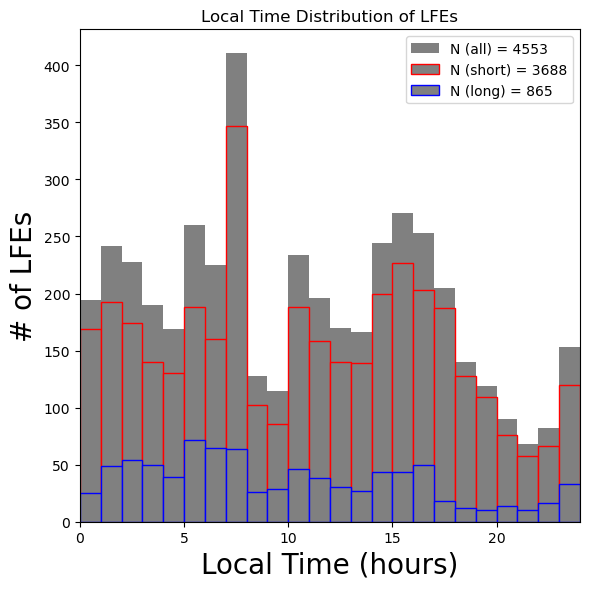

In [3]:
fig, ax = plt.subplots(1, tight_layout=True, sharey = True, figsize=(6,6))

N_LT_Bins=24

ax.hist(np.array(LFE_df['subLST']),color='grey',bins=N_LT_Bins, range=(0,24),label=f"N (all) = {len(LFE_df['subLST'])}")
ax.set_xlim(0,N_LT_Bins)
ax.set_title('Local Time Distribution of LFEs')
ax.set_xlabel('Local Time (hours)',fontsize=20)
ax.set_ylabel('# of LFEs',fontsize=20)


#Now to overplot short LFEs
shortlfes=np.where(LFE_df['duration'] < (11*60*60))  #less than 11 hours
print(len(shortlfes[0]))
ax.hist((LFE_df['subLST'].values[shortlfes[0]]),color='grey',bins=N_LT_Bins,range=(0,24),edgecolor='red',label=f"N (short) = {len(shortlfes[0])}")

#Now to overplot long LFEs
longlfes=np.where(LFE_df['duration'] >= (11*60*60))  #less than 11 hours
print(len(longlfes[0]))
ax.hist((LFE_df['subLST'].values[longlfes[0]]),color='grey',bins=N_LT_Bins,range=(0,24),edgecolor='blue',label=f"N (long) = {len(longlfes[0])}")

plt.legend(loc="upper right")   
plt.savefig("LFE_LocalTimeHist.pdf",format="pdf")
plt.show()


In [4]:
trajectories_df = pd.read_csv("C:/Users/Local Admin/Documents/Data/20040101000000_20170915115700_ephemeris.csv")
#print(trajectories_df)
#print(LFE_df)

In [5]:
#Set histogram bin ranges
range_stepsize=5
range_bins=np.arange(0,max(trajectories_df['R_KSM'])+range_stepsize+1,range_stepsize)
range_centres=(range_bins[:-1]+range_bins[1:])/2

lst_bins=np.arange(0,24+2,1)
lst_centres=(lst_bins[:-1]+lst_bins[1:])/2

lat_stepsize=5
lat_bins=np.arange(-90,90+lat_stepsize,lat_stepsize)
lat_centres=(lat_bins[:-1]+lat_bins[1:])/2

#Make Cassini positional histograms
cassini_range_hist,_=np.histogram(trajectories_df["R_KSM"],bins=range_bins)
cassini_lst_hist,_=np.histogram(trajectories_df["subLST"],bins=lst_bins)
cassini_lat_hist,_=np.histogram(trajectories_df["subLat"],bins=lat_bins)

#Make LFE occurrence histograms
LFE_range_hist,_=np.histogram(LFE_df["R_ksm"],bins=range_bins)
LFE_lst_hist,_=np.histogram(LFE_df["subLST"],bins=lst_bins)
LFE_lat_hist,_=np.histogram(LFE_df["subLat"],bins=lat_bins)


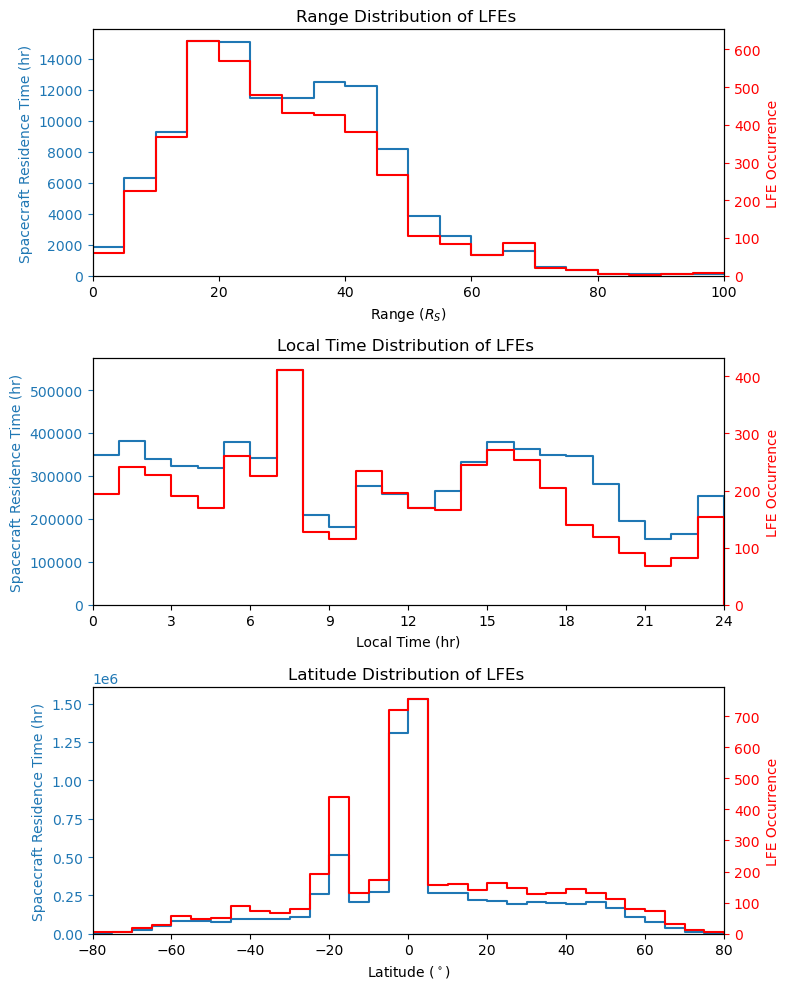

In [9]:
  #####################Un-normalised plot#####################################
fig, ax = plt.subplots(3, figsize = (8,10))

    # AX[0] = RANGE
ax[0].set_title("Range Distribution of LFEs ")
p0=ax[0].step(range_bins[:-1],cassini_range_hist/60.,where='post',color='C0')  #divide by 60 to convert to hours
ax[0].set_xlim(0, 100)
ax[0].set_ylim(0)
ax[0].set_xlabel("Range ($R_S$)")
ax[0].set_ylabel("Spacecraft Residence Time (hr)", fontsize = 10)

twin0 = ax[0].twinx()
p0=twin0.step(range_bins[:-1],LFE_range_hist,where='post',color='red')
twin0.set_ylim(0)
twin0.set_ylabel("LFE Occurrence", fontsize = 10)

ax[0].yaxis.label.set_color('C0')
twin0.yaxis.label.set_color('red')
ax[0].tick_params(axis='y', colors='C0')
twin0.tick_params(axis='y', colors='red')


    # AX[1] = Local Time
ax[1].set_title("Local Time Distribution of LFEs ")
p1=ax[1].step(lst_bins[:-1],cassini_lst_hist,where='post',color='C0')
ax[1].set_xlim(0, 24)
ax[1].set_ylim(0)
ax[1].set_xlabel("Local Time (hr)")
ax[1].set_ylabel("Spacecraft Residence Time (hr)", fontsize = 10)

LTxticks=np.arange(0,27,3)
#print(LTxticks)
ax[1].set_xticks(LTxticks)


twin1 = ax[1].twinx()
p1=twin1.step(lst_bins[:-1],LFE_lst_hist,where='post',color='red')
twin1.set_ylim(0)
twin1.set_ylabel("LFE Occurrence", fontsize = 10)

ax[1].yaxis.label.set_color('C0')
twin1.yaxis.label.set_color('red')
ax[1].tick_params(axis='y', colors='C0')
twin1.tick_params(axis='y', colors='red')



    # AX[2] = Latitude
ax[2].set_title("Latitude Distribution of LFEs ")
p2=ax[2].step(lat_bins[:-1],cassini_lat_hist,where='post',color='C0')
ax[2].set_xlim(-80, 80)
ax[2].set_ylim(0)
ax[2].set_xlabel("Latitude ($^\circ$)")
ax[2].set_ylabel("Spacecraft Residence Time (hr)", fontsize = 10)

twin2 = ax[2].twinx()
p2=twin2.step(lat_bins[:-1],LFE_lat_hist,where='post',color='red')
twin2.set_ylim(0)
twin2.set_ylabel("LFE Occurrence", fontsize = 10)

ax[2].yaxis.label.set_color('C0')
twin2.yaxis.label.set_color('red')
ax[2].tick_params(axis='y', colors='C0')
twin2.tick_params(axis='y', colors='red')



"""
#to check feb 5th I'm happy with normalisation.. talk to D.
ax[2].set_title("Normalised Range Distribution of LFEs ")
ax[2].step(range_bins[:-1],(cassini_range_hist/sum(cassini_range_hist)),where='post',color='C0')  #divide by 60 to convert to hours
ax[2].set_xlim(0, 100)
ax[2].set_xlabel("Range Bins (Saturn Radii)")
ax[2].set_ylabel("Normalised Spacecraft Residence Time", fontsize = 10)

twin2 = ax[2].twinx()
twin2.step(range_bins[:-1],LFE_range_hist/(cassini_range_hist/60.),where='post',color='red')
#twin1.set_ylim(0)
twin2.set_ylabel("LFE Occurrence Rate (per hour)", fontsize = 10)

ax[2].yaxis.label.set_color('blue')
twin2.yaxis.label.set_color('red')
ax[2].tick_params(axis='y', colors='blue')
twin2.tick_params(axis='y', colors='red')
"""   
    
plt.tight_layout()    
plt.savefig("LFE_histograms_Unnormalised_new.pdf",format="pdf")
plt.show()    

C:\Users\Local Admin\AppData\Local\Temp\ipykernel_11952\1604960640.py:34: RuntimeWarning: invalid value encountered in divide
  p1=twin1.step(lst_bins[:-1],LFE_lst_hist/(cassini_lst_hist/60.),where='post',color='red')
C:\Users\Local Admin\AppData\Local\Temp\ipykernel_11952\1604960640.py:58: RuntimeWarning: invalid value encountered in divide
  p2=twin2.step(lat_bins[:-1],LFE_lat_hist/(cassini_lat_hist/60.),where='post',color='red')


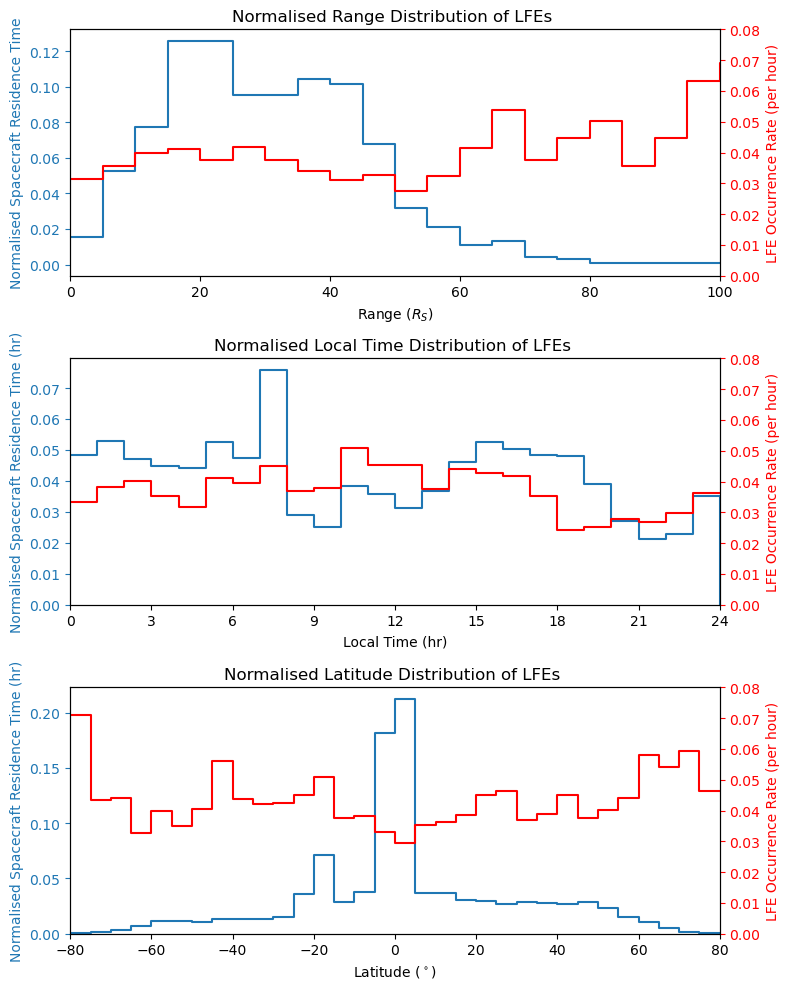

In [10]:
#Normalised Plot
  #####################Un-normalised plot#####################################
fig, ax = plt.subplots(3, figsize = (8,10))

    # AX[0] = RANGE
ax[0].set_title("Normalised Range Distribution of LFEs ")
ax[0].step(range_bins[:-1],(cassini_range_hist/sum(cassini_range_hist)),where='post',color='C0')  #divide by 60 to convert to hours
ax[0].set_xlim(0, 100)
ax[0].set_xlabel("Range ($R_S$)")
ax[0].set_ylabel("Normalised Spacecraft Residence Time", fontsize = 10)

twin0 = ax[0].twinx()
twin0.step(range_bins[:-1],LFE_range_hist/(cassini_range_hist/60.),where='post',color='red')
twin0.set_ylabel("LFE Occurrence Rate (per hour)", fontsize = 10)

ax[0].yaxis.label.set_color('C0')
twin0.yaxis.label.set_color('red')
#twin0.set_ylim(0)
twin0.set_ylim(0,0.08)
ax[0].tick_params(axis='y', colors='C0')
twin0.tick_params(axis='y', colors='red')



    # AX[1] = Local Time
ax[1].set_title("Normalised Local Time Distribution of LFEs ")
p1=ax[1].step(lst_bins[:-1],(cassini_lst_hist/sum(cassini_lst_hist)),where='post',color='C0')
ax[1].set_xlim(0, 24)
ax[1].set_ylim(0)
ax[1].set_xlabel("Local Time (hr)")
ax[1].set_ylabel("Normalised Spacecraft Residence Time (hr)", fontsize = 10)

twin1 = ax[1].twinx()
p1=twin1.step(lst_bins[:-1],LFE_lst_hist/(cassini_lst_hist/60.),where='post',color='red')
#twin1.set_ylim(0)
#twin1.set_ylim(0,0.1)
twin1.set_ylim(0,0.08)
twin1.set_ylabel("LFE Occurrence Rate (per hour)", fontsize = 10)

ax[1].yaxis.label.set_color('C0')
twin1.yaxis.label.set_color('red')
ax[1].tick_params(axis='y', colors='C0')
twin1.tick_params(axis='y', colors='red')
LTxticks=np.arange(0,27,3)
#print(LTxticks)
ax[1].set_xticks(LTxticks)


    # AX[2] = Latitude
ax[2].set_title("Normalised Latitude Distribution of LFEs ")
p2=ax[2].step(lat_bins[:-1],(cassini_lat_hist/sum(cassini_lat_hist)),where='post',color='C0')
ax[2].set_xlim(-80, 80)
ax[2].set_ylim(0)
ax[2].set_xlabel("Latitude ($^\circ$)")
ax[2].set_ylabel("Normalised Spacecraft Residence Time (hr)", fontsize = 10)

twin2 = ax[2].twinx()
p2=twin2.step(lat_bins[:-1],LFE_lat_hist/(cassini_lat_hist/60.),where='post',color='red')
#twin2.set_ylim(0)
#twin2.set_ylim(0,0.1)
twin2.set_ylim(0,0.08)
twin2.set_ylabel("LFE Occurrence Rate (per hour)", fontsize = 10)

ax[2].yaxis.label.set_color('C0')
twin2.yaxis.label.set_color('red')
ax[2].tick_params(axis='y', colors='C0')
twin2.tick_params(axis='y', colors='red')
    
plt.tight_layout()    
plt.savefig("LFE_histograms_Normalised_new.pdf",format="pdf")
plt.show()